# Lecture Example: Human-Robot Distance

In [1]:
import jax
import jax.numpy as jnp
from stljax.formula import Predicate, Always, Eventually, Until


T = 10
distance = jnp.array([3.0, 2.8, 2.5, 2.2, 1.8, 1.5, 1.2, 0.9, 0.7, 0.6])

# Define the STL specification
d_pred = Predicate("d", lambda x: x)
safety_spec = Always(d_pred >= 1.0)  # G(d >= 1.0)

# Evaluate robustness
robustness = safety_spec(distance)
overall_rob = robustness[0]

print(f"Overall robustness: {overall_rob:.4f}")
print(f"Specification {'SATISFIED' if overall_rob > 0 else 'VIOLATED'}")
# Overall robustness: 0.1000
# Specification SATISFIED

Overall robustness: -0.4000
Specification VIOLATED


In [2]:
import optax
import chex

# Start from the original (violated) signal
signal = jnp.array([3.0, 2.8, 2.5, 2.2, 1.8, 1.5, 1.2, 0.9, 0.7, 0.6])


def loss_fn(sig: chex.Array) -> jnp.ndarray:
    """Loss function to maximize robustness.
    We add a regularization term to keep the optimized signal close to the original."""
    rob = safety_spec(sig)[0]
    reg = 0.1 * jnp.sum((sig - distance) ** 2)  # stay close to original
    return -rob + reg


# Compute gradients and optimize the signal
grad_fn = jax.grad(loss_fn)
optimizer = optax.adam(learning_rate=0.05)
opt_state = optimizer.init(signal)

verbose = True
for i in range(200):
    grads = grad_fn(signal)
    if verbose and i % 20 == 0:
        current_rob = safety_spec(signal)[0]
        print(f"Iteration {i}, Robustness: {current_rob:.4f}, Loss: {loss_fn(signal):.4f}")
        print(f"Gradients: {grads}\n")
    updates, opt_state = optimizer.update(grads, opt_state)
    signal = optax.apply_updates(signal, updates)

# Evaluate the optimized signal
rob_opt = safety_spec(signal)[0]
print(f"Optimized robustness: {rob_opt:.4f}")
print(f"Specification {'SATISFIED' if rob_opt > 0 else 'VIOLATED'}")

Iteration 0, Robustness: -0.4000, Loss: 0.4000
Gradients: [ 0.  0.  0.  0.  0.  0.  0.  0.  0. -1.]

Iteration 20, Robustness: 0.1943, Loss: -0.1224
Gradients: [ 0.          0.          0.          0.          0.          0.
  0.          0.06224835 -0.901135    0.12303116]

Iteration 40, Robustness: 0.5545, Loss: -0.3277
Gradients: [ 0.          0.          0.          0.          0.          0.02114229
  0.07268734  0.13381994  0.17504925 -0.8090994 ]

Iteration 60, Robustness: 0.7584, Loss: -0.3877
Gradients: [ 0.          0.          0.          0.          0.          0.06030064
  0.11839125  0.17787598 -0.7883263   0.23273586]

Iteration 80, Robustness: 0.8405, Loss: -0.3871
Gradients: [ 0.          0.          0.          0.          0.04836998  0.07410868
 -0.87190586  0.19152486  0.2292451   0.26053405]

Iteration 100, Robustness: 0.8713, Loss: -0.3826
Gradients: [ 0.          0.          0.          0.          0.03347003  0.08077841
  0.14735988  0.21055269 -0.76573527  0.25

/opt/conda/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/opt/conda/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/opt/conda/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/opt/conda/lib/python3.12/site-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /opt/conda/lib/python3.12/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /opt/conda/lib/python3.12/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

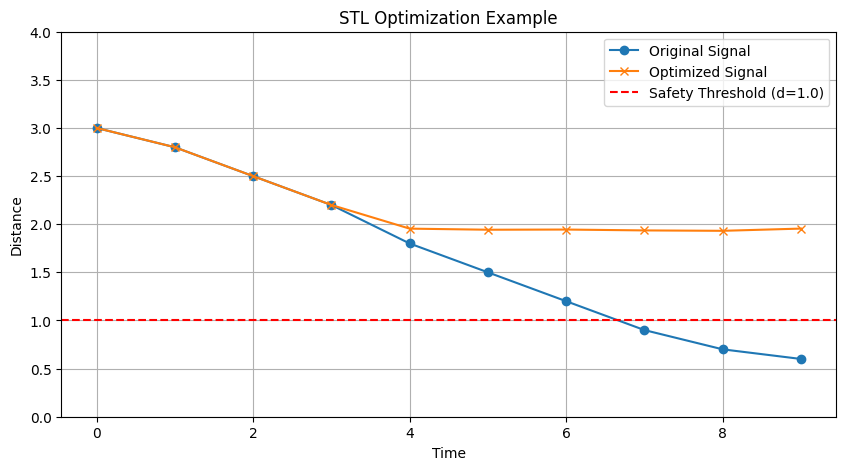

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot original and optimized signals
plt.plot(distance, label="Original Signal", marker="o")
plt.plot(signal, label="Optimized Signal", marker="x")

# Plot the threshold line for safety
plt.axhline(1.0, color="red", linestyle="--", label="Safety Threshold (d=1.0)")


plt.ylim(0, 4)

plt.xlabel("Time")
plt.ylabel("Distance")
plt.title("STL Optimization Example")
plt.legend()
plt.grid(True)
plt.show()